In [38]:
# TODO

# ✅ extract ball centers per frame
# ✅ save CSV of ball trajectory
# ✅ apply Kalman smoothing
# ✅ overlay ball trail on the video
# ✅ create a side-by-side comparison
# ❇️ fully modular helper functions so you don’t re-copy code

In [ ]:
import sys, os
sys.path.append(os.path.abspath("../src"))

import ultralytics
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import yaml
import pandas as pd
import numpy as np

from utils.io_utils import load_config
from utils.io_utils import load_csv_folder
from utils.io_utils import pick_folder

from utils.preprocess_utils import crop_to_freethrow

from utils.freethrow_stats_utils import compute_mean_std_for_alignment

from utils.align_freethrows_utils import align_by_min_unsigned_area
from utils.align_freethrows_utils import apply_shift_to_dataset

from utils.visualize_freethrow_utils import FreeThrowVisualizer

from utils.label_phases_gui import VideoAnnotator

# Load Config 
project_cfg = load_config("project_config.yaml")
ATHLETE = project_cfg["athlete"]
SESSION = project_cfg["session"]

def find_project_root(marker_name="personalized-sports-optimization"):
    p = Path(os.getcwd()).resolve()
    for parent in [p] + list(p.parents):
        if parent.name == marker_name:
            return parent
    raise RuntimeError(f"Project root '{marker_name}' not found")

base_dir = find_project_root()
session_dir = base_dir / "data" / ATHLETE / SESSION
metrics_dir = Path(f"../data/{ATHLETE}/{SESSION}/metrics")
print(base_dir)
print(session_dir)

raw_freethrow_phases_path = metrics_dir / "freethrow_phases.csv"
ball_phases_path = metrics_dir / "ball_phases.csv"
cropped_phases_path = metrics_dir /  "cropped_freethrow_phases.csv"
cropped_phases_df = pd.read_csv(cropped_phases_path)
shift_table_path = metrics_dir / "alignment_shift_table.csv" 

raw_ball_trajectory_path = metrics_dir / "raw_ball_trajectory"
raw_ball_trajectory_path.mkdir(parents=True, exist_ok=True)

# TODO make a function that loads all necessary data frames from data directory 

# Load CSVs
raw_freethrow_phases_df: pd.DataFrame = pd.read_csv(raw_freethrow_phases_path)
cropped_freethrow_phases_df: pd.DataFrame = pd.read_csv(raw_freethrow_phases_path)
angles_unsigned_area_log_df: pd.DataFrame = pd.read_csv(shift_table_path)
ball_phases_df: pd.DataFrame = pd.read_csv(ball_phases_path) if ball_phases_path.exists() else None

print("Ultralytics version:", ultralytics.__version__)
# model = YOLO("yolo11s.pt") # did not recognize as many 
model = YOLO("yolo11m.pt")
# print("Loaded model:", model)

/Users/kwill55/RVL/personalized-sports-optimization
/Users/kwill55/RVL/personalized-sports-optimization/data/tyler_haws/session_with_tyler_haws_gym


FileExistsError: [Errno 17] File exists: '../data/tyler_haws/session_with_tyler_haws_gym/metrics/raw_ball_trajectory'

: 


image 1/1 /Users/kwill55/RVL/personalized-sports-optimization/notebooks/ball_image_2.png: 736x1280 2 persons, 1 sports ball, 1 chair, 420.7ms
Speed: 5.3ms preprocess, 420.7ms inference, 1.8ms postprocess per image at shape (1, 3, 736, 1280)


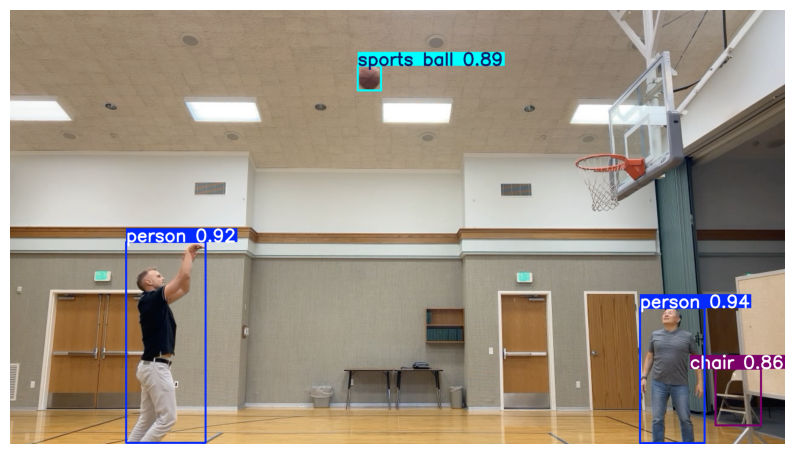

In [ ]:
# ============================
# Run Model on a single image
# ============================

# Path to test image
img_path = "ball_image_2.png"

# Run YOLO on the image
# results = model(img_path)
results = model(img_path, imgsz=1280)

img = results[0].plot() # BGR       
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 

# Plot image within notebook
plt.figure(figsize=(10, 10))
plt.imshow(img_rgb)   # renders YOLO boxes directly
plt.axis("off")
plt.show()

In [ ]:
# ============================
# Run model on single video 
# ============================

RUN = False

if RUN:
    video_path = "../data/tyler_haws/session_with_tyler_haws_gym/videos/ball_tracking/raw/freethrow002.avi"
    model.predict(source=video_path, save=True, conf=0.15)


# TODO -- add dataset of balls near rim/net in order to have the model see them. also try turning up resolution, lowering confidence, etc 

In [ ]:
# ==================================================================
# Run model on all free throws in session and compute ball locations
# ==================================================================

RUN_YOLO_DETECTION = False

if RUN_YOLO_DETECTION:
    folder = pick_folder(session_dir)
    if folder is None:
        raise ValueError("No folder selected.")

    # Collect all free-throw videos
    video_files = sorted([
        f for f in folder.iterdir()
        if f.suffix.lower() in [".avi", ".mp4"]
    ])

    print(f"Found {len(video_files)} videos")

    raw_ball_trajectory_dfs: dict[str, pd.DataFrame] = {}

    for video_path in video_files:

        print(f"\nProcessing: {video_path.name}")

        cap = cv2.VideoCapture(str(video_path))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        # === Create full-length DataFrame with NaNs ===
        df = pd.DataFrame({
            "frame": np.arange(total_frames),
            "x": np.nan,
            "y": np.nan
        })

        frame_idx = 0

        # Process frames
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            results = model(frame, verbose=False, conf=0.4)

            # For each detected object
            for box in results[0].boxes:
                if int(box.cls[0]) == 32:  # sports ball
                    x1, y1, x2, y2 = box.xyxy[0] # YOLO function .xyxy
                    cx = float((x1 + x2) / 2)
                    cy = float((y1 + y2) / 2)

                    # Fill into padded DataFrame
                    df.loc[frame_idx, "x"] = cx
                    df.loc[frame_idx, "y"] = cy

            frame_idx += 1

        cap.release()

        # Save into dict
        freethrow_name = video_path.stem
        raw_ball_trajectory_dfs[freethrow_name] = df

        # Save CSV
        df.to_csv(raw_ball_trajectory_path, index=False)

        # Print coverage
        detected_frames = df["x"].notna().sum()
        print(f"Detected ball in {detected_frames}/{total_frames} frames.")
        print(f"Saved trajectory → {raw_ball_trajectory_path}")

    print("\nFinished processing all videos.")

Found 143 videos

Processing: freethrow001.avi
Detected ball in 3/46 frames.
Saved trajectory → ../data/tyler_haws/session_with_tyler_haws_gym/metrics/raw_ball_trajectory

Processing: freethrow002.avi
Detected ball in 144/170 frames.
Saved trajectory → ../data/tyler_haws/session_with_tyler_haws_gym/metrics/raw_ball_trajectory

Processing: freethrow003.avi
Detected ball in 154/183 frames.
Saved trajectory → ../data/tyler_haws/session_with_tyler_haws_gym/metrics/raw_ball_trajectory

Processing: freethrow004.avi
Detected ball in 79/112 frames.
Saved trajectory → ../data/tyler_haws/session_with_tyler_haws_gym/metrics/raw_ball_trajectory

Processing: freethrow005.avi
Detected ball in 121/149 frames.
Saved trajectory → ../data/tyler_haws/session_with_tyler_haws_gym/metrics/raw_ball_trajectory

Processing: freethrow006.avi
Detected ball in 91/133 frames.
Saved trajectory → ../data/tyler_haws/session_with_tyler_haws_gym/metrics/raw_ball_trajectory

Processing: freethrow007.avi
Detected ball in

KeyboardInterrupt: 

In [ ]:
# ==================================================================
# Debug Visualization: Overlay SAVED x/y trajectories
# ==================================================================

DRAW_TRAJECTORY = False

if DRAW_TRAJECTORY:
    trajectory_folder = raw_ball_trajectory_path  # CSVs
    raw_video_folder = pick_folder(session_dir)       # source videos

    trajectory_video_folder = Path(session_dir) / "videos" / "ball_tracking" / "trajectory"
    trajectory_video_folder.mkdir(parents=True, exist_ok=True)

    csv_files = sorted(trajectory_folder.glob("*.csv"))
    print(f"Found {len(csv_files)} trajectory CSV files\n")

    for csv_path in csv_files:
        name = csv_path.stem
        print(f"Processing {name}...")

        # ----------------------------
        # Match CSV to video
        # ----------------------------
        video_path = raw_video_folder / f"{name}.mp4"
        if not video_path.exists():
            video_path = raw_video_folder / f"{name}.avi"
        if not video_path.exists():
            print(f"❌ No video found for {name}, skipping")
            continue

        # Load trajectory data
        df = pd.read_csv(csv_path)

        if "ball_x" not in df.columns and "x" in df.columns:
            df.rename(columns={"x": "ball_x", "y": "ball_y"}, inplace=True)

        ball_x = df["ball_x"].to_numpy()
        ball_y = df["ball_y"].to_numpy()

        # Open video
        cap = cv2.VideoCapture(str(video_path))
        fps = cap.get(cv2.CAP_PROP_FPS)
        W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        out_video_path = trajectory_video_folder / f"{name}_debug.mp4"

        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        vid_writer = cv2.VideoWriter(str(out_video_path), fourcc, fps, (W, H))

        frame_idx = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            # Only draw if within array bounds
            if frame_idx < len(ball_x):
                bx = ball_x[frame_idx]
                by = ball_y[frame_idx]

                if not np.isnan(bx) and not np.isnan(by):
                    cv2.circle(frame, (int(bx), int(by)), 6, (0, 0, 255), -1)
                else:
                    cv2.putText(frame, "NO BALL DETECTED", (20, 40),
                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 3)

            vid_writer.write(frame)

            frame_idx += 1

        cap.release()
        vid_writer.release()

    print("\nDone! Debug videos saved in:")
    print(f"Trajectory video folder: {trajectory_video_folder}")


In [ ]:
# ==================================================================
# Load ball trajectories and pad all with nans to be the same length 
# ==================================================================
raw_ball_trajectory_dfs: dict[str, pd.DataFrame] = load_csv_folder(raw_ball_trajectory_path)
cropped_ball_trajectory_dfs = crop_to_freethrow(
    angles_dfs = raw_ball_trajectory_dfs, 
    phases_df = ball_phases_df,
    start_col="raw_start_frame",
    end_col="raw_ball_through_net"
    )

max_len = max(len(df) for df in raw_ball_trajectory_dfs.values())
print("Max length:", max_len)

# Pad each DF to max_len with NaNs
padded_ball_trajectory_dfs = {}

for key, df in cropped_ball_trajectory_dfs.items():
    current_len = len(df)
    if current_len < max_len:
        # Create padding rows full of NaNs with same columns
        pad_rows = pd.DataFrame(
            {col: [np.nan] * (max_len - current_len) for col in df.columns}
        )
        # Concatenate original + padding, reset index
        padded = pd.concat([df, pad_rows], ignore_index=True)
    else:
        padded = df.copy()

    padded_ball_trajectory_dfs[key] = padded

#TODO fix this error. but what im really trying to do is see if now that conf is up to .4, do the graphs look better 


✅ Successfully cropped 0 out of 0 freethrow sequences.


ValueError: max() iterable argument is empty

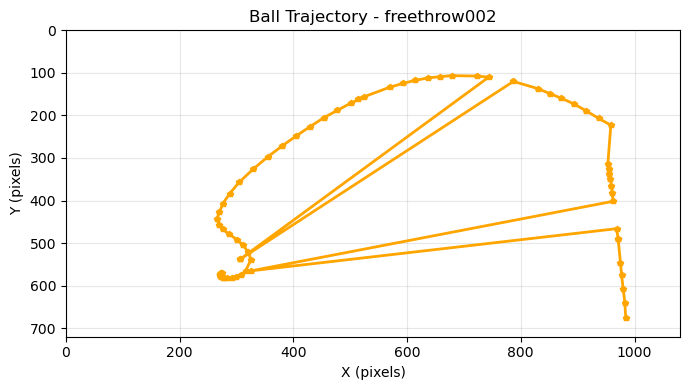

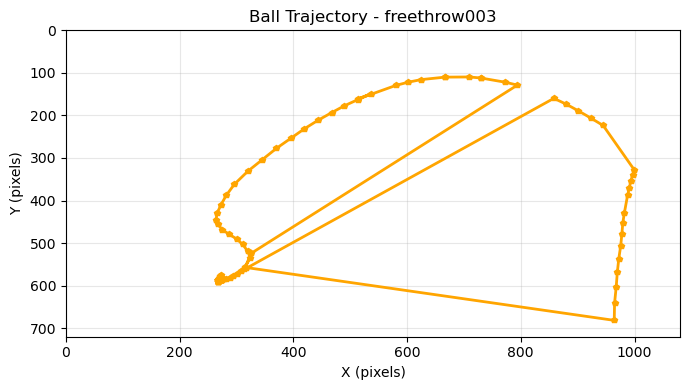

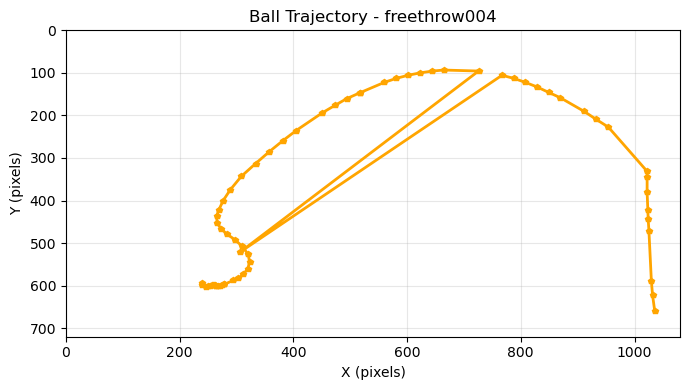

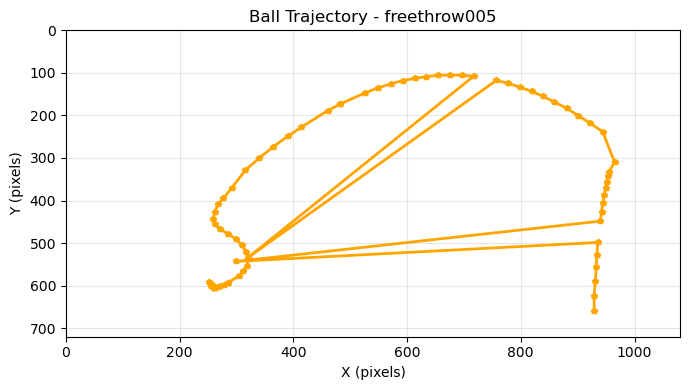

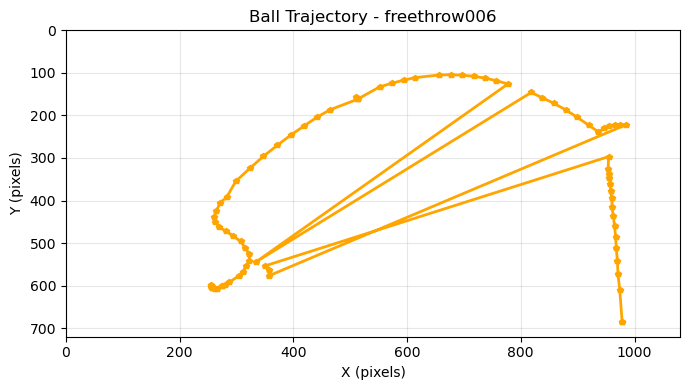

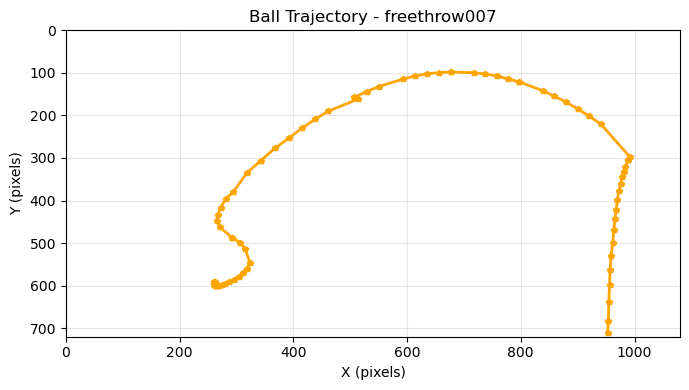

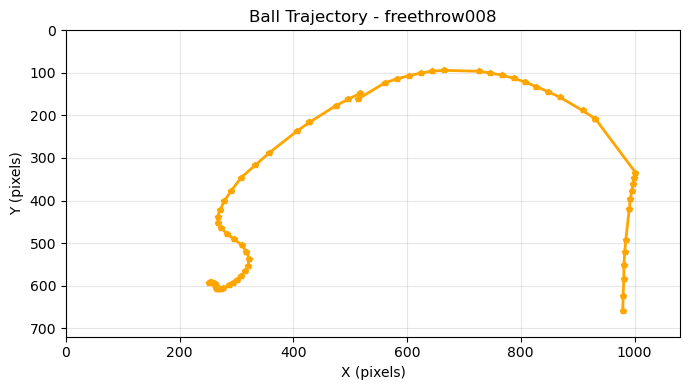

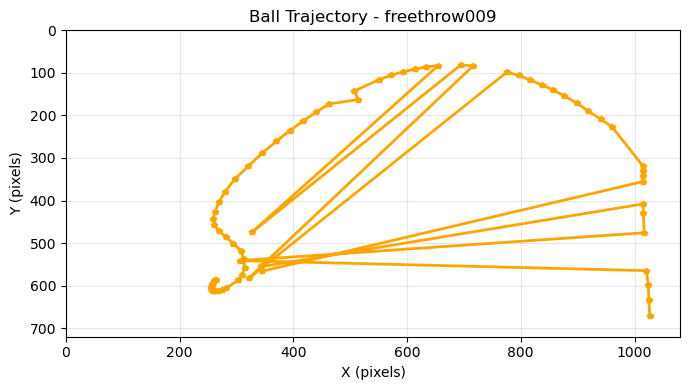

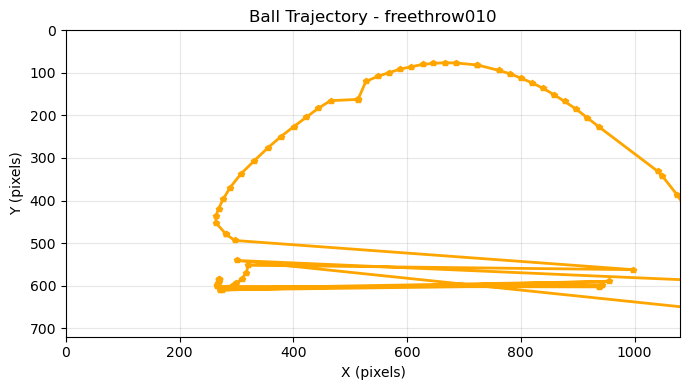

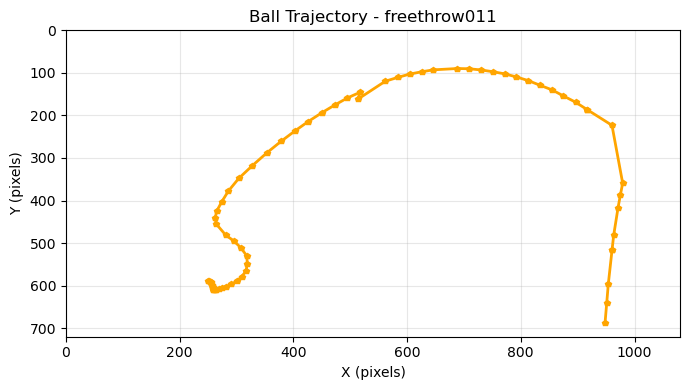

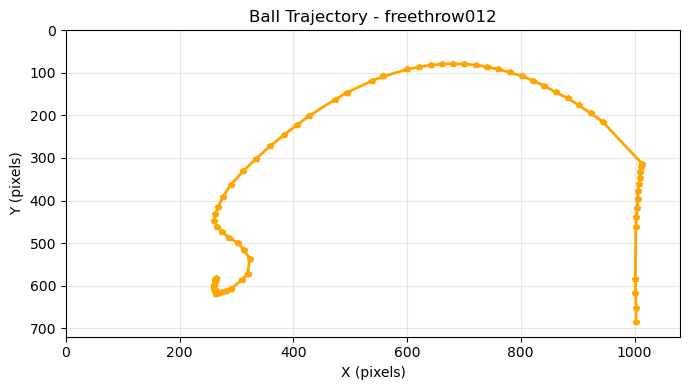

/Users/kwill55/RVL/personalized-sports-optimization/src/utils/visualize_freethrow_utils.py:210: RuntimeWarning: Mean of empty slice
  x = np.nanmean(x_matrix, axis=0)
/Users/kwill55/RVL/personalized-sports-optimization/src/utils/visualize_freethrow_utils.py:211: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)


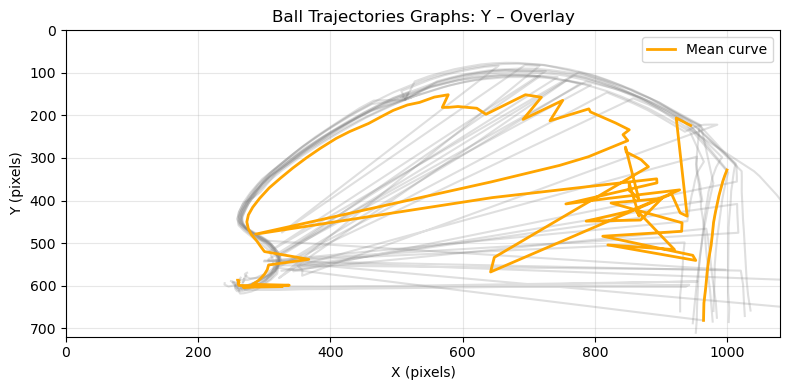

In [ ]:
# ==================================================================
# Draw graph for each trajectory  
# ==================================================================
DRAW_INDIVIDUAL_GRAPHS = True


viz = FreeThrowVisualizer()

if DRAW_INDIVIDUAL_GRAPHS: 
    for freethrow, df in cropped_ball_trajectory_dfs.items():
        viz.plot_single_curve(
            df,
            x_col="x",
            y_col="y",
            title=f"Ball Trajectory - {freethrow}",
            x_label="X (pixels)",
            y_label="Y (pixels)",
            x_min= 0,
            x_max=1080,
            y_min=0,
            y_max=720,
            flip_y_axis=True,
            color="orange",
            marker="p"
        )

viz.plot_multiple_curves(
    dfs_dict=cropped_ball_trajectory_dfs,
    x_col="x",
    y_col="y",
    dataset_name="Ball Trajectories Graphs",
    show_overlay=True,
    show_mean_std=False,
    x_min=0,
    x_max=1080, # TODO constants from config of resolution
    y_min=0,
    y_max=720,
    flip_y_axis=True,
    x_label="X (pixels)",
    y_label="Y (pixels)"
)





# TODO plan!
# compute cropped / aligned trajectories
# plot aligned trajectories as pixels interactive mode and all together 
# plot trajectories as relative distance 





In [ ]:
ball_trajectory_stats = compute_mean_std_for_alignment(
    dfs_dict=raw_ball_trajectory_dfs,
    curve_names="y",
    x_col="x"
)

viz = FreeThrowVisualizer()

viz.interactive_review(
    curve_name="y",
    x_col="x",
    y_col="y",
    dfs_dict= raw_ball_trajectory_dfs,
    stats_dict=ball_trajectory_stats,
)


interactive(children=(IntSlider(value=0, description='Throw Index', max=45), Output()), _dom_classes=('widget-…

<function utils.visualize_freethrow_utils.FreeThrowVisualizer.interactive_review.<locals>.show(idx)>

In [ ]:
unsigned_area_ball_trajectory_stats = compute_mean_std_for_alignment(
    aligned_ball_trajectory_unsigned_area_dfs,
    ball_cols
)

viz = FreeThrowVisualizer(
    y_label="Height(units?)",
    title_label="Ball Trajectory"
)

viz.interactive_review(
    curve_name="y",
    dfs_dict= aligned_ball_trajectory_unsigned_area_dfs,
    stats_dict=unsigned_area_ball_trajectory_stats,
)

NameError: name 'aligned_ball_trajectory_unsigned_area_dfs' is not defined

In [ ]:
dataset structure in files: 

dataset/
   images/
       train/
       val/
   labels/
       train/
       val/
data.yaml


data.yaml file: 

train: dataset/images/train
val: dataset/images/val

names:
  0: sports_ball

SyntaxError: invalid syntax (2264983031.py, line 1)

In [ ]:
#Train YOLO on Mac

model = YOLO("yolov11s.pt")

model.train(
    data="data.yaml",
    epochs=10,
    imgsz=640,
    batch=8
)
